# Pipeline 1: HF-Backed Training and Evaluation

This notebook runs the end-to-end Module 2 pipeline:
- loads local feature artifacts from Kaggle inputs
- pulls daily labels from Hugging Face
- builds sequential train / validation / test loaders
- trains the current-risk model
- evaluates thresholds, plots metrics, exports predictions, and runs SHAP

The notebook is organized into short stages so each step can be rerun independently when debugging Kaggle or HF input issues.

## Kaggle Inputs Checklist
- `probablyonfire-code` for the shared project code
- `probablyonfire-features` for the feature parquet and channel map
- `probablyonfire-database` for the HF fetcher / loader utilities
- `HUGGINGFACE_TOKEN` in Kaggle Secrets for label download


## Environment Setup

Import the standard library, numerical stack, PyTorch, and plotting tools used throughout the pipeline. This is the minimal runtime bootstrap for the notebook.


In [2]:
import os
import sys
import json
import random
import shutil
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

## Paths and Hyperparameters

Define the Kaggle input locations, date windows, model settings, optimization parameters, and output paths used by the rest of the notebook.


In [3]:
CODE_INPUT_CANDIDATES = [
    Path('/kaggle/input/probablyonfire-codebase')
]
FEATURE_INPUT_CANDIDATES = [
    Path('/kaggle/input/probablyOnFire')
]
DATABASE_INPUT_CANDIDATES = [
    Path('/kaggle/input/probablyonfire-database'),
    Path('/kaggle/input/probablyonfire-database/database')
]

# Label source on Hugging Face (must contain columns: timestamp, label)
LABEL_REPO_ID = 'NagrajMG/SmokyPixels'
LABEL_SPLIT = 'train'
LABEL_TIMESTAMP_COL = 'timestamp'
LABEL_MAP_COL = 'label'

# Training date ranges (Module 2)
TRAIN_START = '2012-01-01'
TRAIN_END   = '2021-12-31'
VAL_START   = '2022-01-01'
VAL_END     = '2022-12-31'
TEST_START  = '2023-01-01'
TEST_END    = '2023-12-31'

# Model/training hyperparameters
BATCH_SIZE = 8
HISTORY = 15
ARCH = 'cnn_biconvlstm'
HIDDEN_CHANNELS = 32
N_LAYERS = 1
KERNEL_SIZE = 3
DROPOUT = 0.2
ENCODER_WIDTHS = [64, 128, 256]
TEMPORAL_HIDDEN = 128
TEMPORAL_LAYERS = 2
TEMPORAL_BIDIRECTIONAL = True
DECODER_CHANNELS = [256, 128, 64]

EPOCHS = 20
LR = 3e-4
WEIGHT_DECAY = 1e-2
GRAD_CLIP_NORM = 1.0
PATIENCE = 3
USE_AMP = True
OBJECTIVE = 'focal'   # 'bce' or 'focal'
FOCAL_ALPHA = 0.25
FOCAL_GAMMA = 2.0

NUM_WORKERS = 0
SEED = 42

# Output paths
WORKDIR = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path.cwd()
CHECKPOINT_PATH = WORKDIR / 'checkpoints' / 'current_probability_best.pt'
METRICS_PATH = WORKDIR / 'module2_metrics.json'

# Optional publish
PUBLISH_TO_HF_MODEL = False
HF_MODEL_REPO_ID = 'NagrajMG/california_wildfire_model'
HF_MODEL_FILENAME = 'current_probability_best.pt'

## Shared Helpers

Set reproducibility utilities and conversion helpers for nested parquet objects, timestamps, and other small transformations used by multiple later cells.


In [4]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def resolve_existing_path(candidates):
    for p in candidates:
        if p.exists():
            return p
    return None


def to_feature_cube(x: object) -> torch.Tensor:
    """Convert nested parquet object into float32 tensor [C,H,W]."""
    arr = np.asarray(x, dtype=object)
    if arr.ndim == 3 and arr.dtype != object:
        out = arr.astype(np.float32)
        return torch.from_numpy(out)

    # Typical nested representation: list/array of channels, each [H,W]
    channels = []
    for ch in arr:
        ch_arr = np.asarray(ch, dtype=object)
        if ch_arr.ndim == 2 and ch_arr.dtype != object:
            channels.append(ch_arr.astype(np.float32))
        else:
            rows = [np.asarray(r, dtype=np.float32) for r in ch_arr]
            channels.append(np.stack(rows, axis=0))
    out = np.stack(channels, axis=0).astype(np.float32)
    return torch.from_numpy(out)


def to_day_start_timestamp(v) -> int:
    ts = int(v)
    return (ts // 86_400) * 86_400


def add_days(ts: int, days: int) -> int:
    return to_day_start_timestamp(ts) + int(days) * 86_400


def to_ts(d: str) -> int:
    return int(datetime.fromisoformat(d).replace(tzinfo=timezone.utc).timestamp())


## Resolve Kaggle Inputs

Locate the mounted Kaggle datasets and confirm the code, feature, and database inputs are available before any model work starts.


In [5]:
# -------------------------
# Resolve code + feature inputs (Kaggle)
# -------------------------
from pathlib import Path
import shutil
import sys

INPUT_ROOT = Path("/kaggle/input")
WORKDIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path.cwd()

def pick_existing(paths):
    for p in paths:
        if p.exists():
            return p
    return None

def find_file(root: Path, filename: str):
    hits = list(root.rglob(filename))
    return hits[0] if hits else None

# Kaggle dataset mounts (add more candidates if your slugs differ)
feature_input = pick_existing([
    INPUT_ROOT / "datasets/nagrajgaonkar/probablyonfire"
])

code_input = pick_existing([
    INPUT_ROOT / "datasets/nagrajgaonkar/probablyonfire-codebase"
])

db_input = pick_existing([
    INPUT_ROOT / "datasets/nagrajgaonkar/probablyonfire-database"
])

if feature_input is None:
    raise FileNotFoundError("Feature dataset not found. Expected /kaggle/input/probablyonfire")
if code_input is None:
    raise FileNotFoundError("Code dataset not found. Expected /kaggle/input/probablyonfire-codebase")
if db_input is None:
    raise FileNotFoundError("Database dataset not found. Expected /kaggle/input/probablyonfire-database")

# Locate required feature files (works even if nested)
feature_parquet = find_file(feature_input, "features_daily_normalized.parquet")
channel_map_csv = find_file(feature_input, "channel_index_map.csv")
if feature_parquet is None:
    raise FileNotFoundError(f"features_daily_normalized.parquet not found under {feature_input}")
if channel_map_csv is None:
    raise FileNotFoundError(f"channel_index_map.csv not found under {feature_input}")

# Build working project layout
project_root = WORKDIR / "ProbablyOnFire"
project_root.mkdir(parents=True, exist_ok=True)

# Resolve module2 root in code dataset:
# case A: code_input/module 2/src/current_probability
# case B: code_input/src/current_probability (already module2 root)
if (code_input / "module 2" / "src" / "current_probability").exists():
    module2_src_root = code_input / "module 2"
elif (code_input / "src" / "current_probability").exists():
    module2_src_root = code_input
else:
    raise FileNotFoundError(
        f"Could not find module 2 source in {code_input}. "
        "Expected either 'module 2/src/current_probability' or 'src/current_probability'."
    )

# Copy module 2 into /kaggle/working/ProbablyOnFire/module 2
shutil.copytree(module2_src_root, project_root / "module 2", dirs_exist_ok=True)

# Copy database package into /kaggle/working/ProbablyOnFire/database
db_src = db_input / "database" if (db_input / "database").exists() else db_input
if not (db_src / "__init__.py").exists():
    raise FileNotFoundError(f"Database package not found under {db_input}")
shutil.copytree(db_src, project_root / "database", dirs_exist_ok=True)

# Import paths
module2_src = project_root / "module 2" / "src"
if not (module2_src / "current_probability").exists():
    raise FileNotFoundError(f"Module2 package missing at {module2_src / 'current_probability'}")

sys.path.insert(0, str(project_root))
sys.path.insert(0, str(module2_src))

print("project_root:", project_root)
print("module2_src:", module2_src)
print("database_dir:", project_root / "database")
print("feature_parquet:", feature_parquet)
print("channel_map_csv:", channel_map_csv)

set_seed(SEED)


project_root: /kaggle/working/ProbablyOnFire
module2_src: /kaggle/working/ProbablyOnFire/module 2/src
database_dir: /kaggle/working/ProbablyOnFire/database
feature_parquet: /kaggle/input/datasets/nagrajgaonkar/probablyonfire/features_daily_normalized.parquet
channel_map_csv: /kaggle/input/datasets/nagrajgaonkar/probablyonfire/channel_index_map.csv


## Hugging Face Authentication

Load the `HUGGINGFACE_TOKEN` secret so the notebook can stream labels from the dataset repo without embedding credentials in the notebook itself.


In [6]:
# -------------------------
# Hugging Face auth for label download
# -------------------------
# Kaggle Secret path
try:
    from kaggle_secrets import UserSecretsClient
    token = UserSecretsClient().get_secret('HUGGINGFACE_TOKEN')
    os.environ['HUGGINGFACE_TOKEN'] = token
    print('Loaded HUGGINGFACE_TOKEN from Kaggle Secrets.')
except Exception:
    if os.getenv('HUGGINGFACE_TOKEN'):
        print('Using existing HUGGINGFACE_TOKEN from environment.')
    else:
        raise RuntimeError('HUGGINGFACE_TOKEN not found. Add it in Kaggle Secrets.')


Loaded HUGGINGFACE_TOKEN from Kaggle Secrets.


## Import Project Modules

Bring in the local `current_probability` package and database fetcher helpers from the code input. These define the loader, model, and training entry points used by the pipeline.


In [7]:
from database.fetcher import load_heatmap_lookup
from current_probability.data import Module2HFStreamConfig, make_hf_sequential_loader
from current_probability.model import build_current_risk_model
from current_probability.train import TrainConfig, fit, evaluate

## Load Local Features

Read the feature parquet, normalize timestamps to UTC day-start, and verify that the spatial feature cube is consistent across samples.


In [8]:
# -------------------------
# Load local features
# -------------------------
feat_df = pd.read_parquet(feature_parquet)
if 'timestamp' not in feat_df.columns or 'feature_map' not in feat_df.columns:
    raise ValueError('features_daily_normalized.parquet must contain timestamp and feature_map columns')

feat_df = feat_df.sort_values('timestamp').reset_index(drop=True)
feat_df['timestamp'] = feat_df['timestamp'].astype('int64').map(to_day_start_timestamp)

channel_map = pd.read_csv(channel_map_csv).sort_values('channel_index').reset_index(drop=True)
feature_names = channel_map['feature_name'].tolist()

feature_rows_all = []
for _, row in feat_df[['timestamp', 'feature_map']].iterrows():
    ts = int(row['timestamp'])
    fmap = to_feature_cube(row['feature_map'])
    feature_rows_all.append((ts, fmap, None))  # valid_mask not provided

# Validate shape consistency
c0, h0, w0 = feature_rows_all[0][1].shape
for ts, fmap, _ in feature_rows_all[1:20]:
    if tuple(fmap.shape) != (c0, h0, w0):
        raise ValueError(f'Inconsistent feature_map shape at ts={ts}: {tuple(fmap.shape)} != {(c0,h0,w0)}')

print('Feature rows:', len(feature_rows_all))
print('Feature shape [C,H,W]:', (c0, h0, w0))
print('Channels:', len(feature_names))
print('Feature date range:',
      pd.to_datetime(feature_rows_all[0][0], unit='s', utc=True).date(), '->',
      pd.to_datetime(feature_rows_all[-1][0], unit='s', utc=True).date())


Feature rows: 4363
Feature shape [C,H,W]: (16, 40, 42)
Channels: 16
Feature date range: 2012-01-21 -> 2023-12-31


## Label Conversion Helpers

Convert the nested HF label objects into dense 2D NumPy arrays so they can be aligned with the feature cubes and training masks.


In [9]:
def to_label_2d(x) -> np.ndarray:
    # Fast path
    try:
        arr = np.asarray(x, dtype=np.float32)
        if arr.ndim == 2:
            return arr
    except Exception:
        pass

    # Object/nested path
    obj = np.asarray(x, dtype=object)

    if obj.ndim == 2:
        return obj.astype(np.float32)

    if obj.ndim == 1:
        rows = [np.asarray(r, dtype=np.float32).reshape(-1) for r in obj]
        widths = {r.shape[0] for r in rows}
        if len(widths) != 1:
            raise ValueError(f"Inconsistent row widths in label map: {sorted(widths)}")
        return np.stack(rows, axis=0).astype(np.float32)

    raise ValueError(f"Unsupported label map format: shape={obj.shape}, ndim={obj.ndim}")

## Load Labels and Mask

Download the daily label parquet and the fixed training mask from Hugging Face, then normalize both into a consistent 2D tensor representation.


In [10]:
# -------------------------
# Load labels + fixed training mask from HF (strict)
# -------------------------
from huggingface_hub import hf_hub_download

LABEL_FILE_CANDIDATES = ["labels.parquet", "LABELS/labels.parquet"]
MASK_FILE_CANDIDATES = ["mask.parquet", "LABELS/mask.parquet"]
MASK_COL_CANDIDATES = ["training_mask", "mask", "label_mask", "heatmap"]
REQUIRE_TRAINING_MASK = True

def hf_download_first(repo_id: str, candidates: list[str], token: str | None):
    errors = []
    for fn in candidates:
        try:
            p = hf_hub_download(
                repo_id=repo_id,
                repo_type="dataset",
                filename=fn,
                token=token,
            )
            return p, fn
        except Exception as e:
            errors.append(f"{fn}: {e}")
    raise FileNotFoundError(
        f"None of these files found in {repo_id}: {candidates}\n" + "\n".join(errors)
    )

def to_2d_float(x) -> np.ndarray:
    # fast path
    try:
        arr = np.asarray(x, dtype=np.float32)
        if arr.ndim == 2:
            return arr
    except Exception:
        pass

    # nested object path
    obj = np.asarray(x, dtype=object)
    if obj.ndim == 2:
        return obj.astype(np.float32)

    if obj.ndim == 1:
        rows = [np.asarray(r, dtype=np.float32).reshape(-1) for r in obj]
        widths = {r.shape[0] for r in rows}
        if len(widths) != 1:
            raise ValueError(f"Inconsistent row widths in 2D map: {sorted(widths)}")
        return np.stack(rows, axis=0).astype(np.float32)

    raise ValueError(f"Unsupported map format: shape={obj.shape}, ndim={obj.ndim}")

def to_2d_bool_mask(x) -> torch.Tensor:
    m = to_2d_float(x)
    return torch.from_numpy((m > 0.5).astype(np.bool_))

global_start = min(TRAIN_START, VAL_START, TEST_START)
global_end = max(TRAIN_END, VAL_END, TEST_END)
start_ts = to_day_start_timestamp(to_ts(global_start))
end_ts = to_day_start_timestamp(to_ts(global_end))
token = os.environ.get("HUGGINGFACE_TOKEN")

# ---- labels
labels_fp, labels_fn = hf_download_first(LABEL_REPO_ID, LABEL_FILE_CANDIDATES, token)
labels_df = pd.read_parquet(labels_fp)

if LABEL_TIMESTAMP_COL not in labels_df.columns or LABEL_MAP_COL not in labels_df.columns:
    raise ValueError(
        f"{labels_fn} must contain '{LABEL_TIMESTAMP_COL}' and '{LABEL_MAP_COL}'. "
        f"Found: {labels_df.columns.tolist()}"
    )

labels_df = labels_df[[LABEL_TIMESTAMP_COL, LABEL_MAP_COL]].copy()
labels_df[LABEL_TIMESTAMP_COL] = labels_df[LABEL_TIMESTAMP_COL].astype("int64").map(to_day_start_timestamp)
labels_df = labels_df.sort_values(LABEL_TIMESTAMP_COL).drop_duplicates(LABEL_TIMESTAMP_COL, keep="last")
labels_df = labels_df[
    (labels_df[LABEL_TIMESTAMP_COL] >= start_ts) &
    (labels_df[LABEL_TIMESTAMP_COL] <= end_ts)
].reset_index(drop=True)

label_lookup_all = {}
for _, r in labels_df.iterrows():
    ts = int(r[LABEL_TIMESTAMP_COL])
    y_np = to_2d_float(r[LABEL_MAP_COL])
    y = torch.from_numpy(y_np).to(torch.float32)
    y = torch.nan_to_num(y, nan=0.0).clamp(0.0, 1.0)
    label_lookup_all[ts] = y

# ---- mask (strict)
mask_fp, mask_fn = hf_download_first(LABEL_REPO_ID, MASK_FILE_CANDIDATES, token)
mask_df = pd.read_parquet(mask_fp)
print("mask file:", mask_fn, "columns:", mask_df.columns.tolist(), "rows:", len(mask_df))

mask_col = next((c for c in MASK_COL_CANDIDATES if c in mask_df.columns), None)
if mask_col is None:
    raise ValueError(f"No mask column found in {mask_fn}. Expected one of {MASK_COL_CANDIDATES}")

training_mask_bool = to_2d_bool_mask(mask_df.iloc[0][mask_col])

# sanity
sample_keys = list(label_lookup_all.keys())[:20]
for k in sample_keys:
    vals = torch.unique(label_lookup_all[k])
    if not torch.all((vals == 0) | (vals == 1)):
        raise ValueError(f"Non-binary label values at {k}: {vals.tolist()}")

if sample_keys:
    label_shape = tuple(label_lookup_all[sample_keys[0]].shape)
    if tuple(training_mask_bool.shape) != label_shape:
        raise ValueError(
            f"Mask shape {tuple(training_mask_bool.shape)} != label shape {label_shape}"
        )

print("Labels loaded:", len(label_lookup_all))
if sample_keys:
    print("Label shape [H,W]:", tuple(label_lookup_all[sample_keys[0]].shape))
    print(
        "Label date range:",
        pd.to_datetime(min(label_lookup_all.keys()), unit="s", utc=True).date(),
        "->",
        pd.to_datetime(max(label_lookup_all.keys()), unit="s", utc=True).date(),
    )
print("Training mask loaded:", training_mask_bool is not None)
print("Mask shape:", tuple(training_mask_bool.shape), "coverage:", float(training_mask_bool.float().mean()))


labels.parquet:   0%|          | 0.00/149k [00:00<?, ?B/s]

mask.parquet:   0%|          | 0.00/2.36k [00:00<?, ?B/s]

mask file: mask.parquet columns: ['mask_id', 'training_mask'] rows: 1
Labels loaded: 4363
Label shape [H,W]: (40, 42)
Label date range: 2012-01-21 -> 2023-12-31
Training mask loaded: True
Mask shape: (40, 42) coverage: 0.699999988079071


## Build Sequential Loaders

Assemble the per-split temporal windows that feed the model. This is where the feature rows, labels, and masks are aligned into train / validation / test loaders.


In [11]:
# -------------------------
# Build sequential loaders using local feature rows + HF label lookup (+ fixed mask)
# -------------------------
USE_TRAINING_MASK_AS_VALID_MASK = True   # recommended
USE_MASKED_LABEL_TARGET = False          # keep labels original; mask only loss region

def make_split_loader(start_date: str, end_date: str, batch_size: int):
    start_ts = to_day_start_timestamp(to_ts(start_date))
    end_ts = to_day_start_timestamp(to_ts(end_date))
    prehist_start_ts = add_days(start_ts, -(HISTORY - 1))

    split_feature_rows = []
    for (ts, fmap, vmask) in feature_rows_all:
        if prehist_start_ts <= ts <= end_ts:
            final_mask = vmask
            if USE_TRAINING_MASK_AS_VALID_MASK and training_mask_bool is not None:
                final_mask = training_mask_bool   # same [H,W] mask for every day
            split_feature_rows.append((ts, fmap, final_mask))

    split_labels = {}
    for ts, y in label_lookup_all.items():
        if start_ts <= ts <= end_ts:
            yy = y
            if USE_MASKED_LABEL_TARGET and training_mask_bool is not None:
                yy = yy * training_mask_bool.to(dtype=yy.dtype)
            split_labels[ts] = yy

    cfg = Module2HFStreamConfig(
        start_date=start_date,
        end_date=end_date,
        history=HISTORY,
        batch_size=batch_size,
        feature_repo_id='local_features_override',
        label_repo_id=LABEL_REPO_ID,
        split=LABEL_SPLIT,
        feature_timestamp_col='timestamp',
        feature_map_col='feature_map',
        feature_valid_mask_col='valid_mask' if USE_TRAINING_MASK_AS_VALID_MASK else None,
        label_timestamp_col=LABEL_TIMESTAMP_COL,
        label_map_col=LABEL_MAP_COL,
    )

    loader = make_hf_sequential_loader(
        cfg,
        feature_rows_override=split_feature_rows,
        label_lookup_override=split_labels,
        num_workers=NUM_WORKERS,
    )
    return loader

train_loader = make_split_loader(TRAIN_START, TRAIN_END, BATCH_SIZE)
val_loader = make_split_loader(VAL_START, VAL_END, BATCH_SIZE)
test_loader = make_split_loader(TEST_START, TEST_END, BATCH_SIZE)

# Batch contract sanity
batch0 = next(iter(train_loader))
print('train batch x:', tuple(batch0['x'].shape))
print('train batch y:', tuple(batch0['y'].shape))
print('train batch mask:', tuple(batch0['mask'].shape))
print('train batch first date:', pd.to_datetime(batch0['date'][0], unit='s', utc=True).date())
print('mask coverage in first batch:', float(batch0['mask'].float().mean()))

train batch x: (8, 15, 16, 40, 42)
train batch y: (8, 40, 42)
train batch mask: (8, 40, 42)
train batch first date: 2012-02-04
mask coverage in first batch: 0.699999988079071


## Batch Sanity Check

Inspect a representative batch before training so shape issues surface early, while the data path is still easy to debug.


In [12]:
# Batch contract sanity
batch1 = next(iter(val_loader))
print('val batch x:', tuple(batch1['x'].shape))
print('val batch y:', tuple(batch1['y'].shape))
print('val batch mask:', tuple(batch1['mask'].shape))
print('val batch first date:', pd.to_datetime(batch1['date'][0], unit='s', utc=True).date())
print('mask coverage in val batch:', float(batch1['mask'].float().mean()))

val batch x: (8, 15, 16, 40, 42)
val batch y: (8, 40, 42)
val batch mask: (8, 40, 42)
val batch first date: 2022-01-01
mask coverage in val batch: 0.699999988079071


## Model Definition and Training

Instantiate the current-risk model, build the training config, and move the model onto the available device before fitting.


In [13]:
# -------------------------
# Build model + train (weights included via pos_weight inside fit)
# -------------------------
C = int(batch0['x'].shape[2])
H = int(batch0['x'].shape[3])
W = int(batch0['x'].shape[4])

if (H, W) != tuple(batch0['y'].shape[-2:]):
    raise ValueError('Feature spatial shape and label spatial shape mismatch')

model = build_current_risk_model(
    arch=ARCH,
    in_channels=C,
    hidden_channels=HIDDEN_CHANNELS,
    n_layers=N_LAYERS,
    kernel_size=KERNEL_SIZE,
    dropout=DROPOUT,
    encoder_widths=ENCODER_WIDTHS,
    temporal_hidden=TEMPORAL_HIDDEN,
    temporal_layers=TEMPORAL_LAYERS,
    temporal_bidirectional=TEMPORAL_BIDIRECTIONAL,
    decoder_channels=DECODER_CHANNELS,
)

tcfg = TrainConfig(
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    grad_clip_norm=GRAD_CLIP_NORM,
    patience=PATIENCE,
    use_amp=USE_AMP,
    objective=OBJECTIVE,
    focal_alpha=FOCAL_ALPHA,
    focal_gamma=FOCAL_GAMMA,
    ckpt_path=str(CHECKPOINT_PATH),
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


## Fit and Evaluate

Train the model with the configured budget, then evaluate on the held-out test split.


In [14]:
model, best_val = fit(model, train_loader, val_loader, tcfg, device)
test_loss = evaluate(model, test_loader, tcfg, device, pos_weight=None)

print(f'best_val={best_val:.6f}')
print(f'test_loss={test_loss:.6f}')

epoch=1 val_loss=0.145321
epoch=2 val_loss=0.135391
epoch=3 val_loss=0.124639
epoch=4 val_loss=0.121607
epoch=5 val_loss=0.117534
epoch=6 val_loss=0.112563
epoch=7 val_loss=0.112644
epoch=8 val_loss=0.110305
epoch=9 val_loss=0.110695
epoch=10 val_loss=0.112748
epoch=11 val_loss=0.109511
epoch=12 val_loss=0.106974
epoch=13 val_loss=0.106586
epoch=14 val_loss=0.105934
epoch=15 val_loss=0.110581
epoch=16 val_loss=0.109786
epoch=17 val_loss=0.108215
early stopping
best_val=0.105934
test_loss=0.044343


## Metrics Collection

Collect pixel-level probabilities, sweep thresholds on validation, and save the summary metrics needed for reporting.


In [15]:
# -------------------------
# Save metrics + quantitative eval + qualitative plots + metrics matrix
# -------------------------
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, confusion_matrix,
    precision_recall_curve
)

CHECKPOINT_PATH.parent.mkdir(parents=True, exist_ok=True)

def collect_pixel_scores(loader, model, device):
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for batch in loader:
            x = batch["x"].to(device, non_blocking=True)
            y = batch["y"].cpu().numpy().astype(np.uint8)  # [B,H,W]

            m = batch.get("mask")
            if m is None:
                m = np.ones_like(y, dtype=bool)
            else:
                m = m.cpu().numpy().astype(bool)           # [B,H,W]

            p = torch.sigmoid(model(x)).cpu().numpy().astype(np.float32)  # [B,H,W]
            ys.append(y[m])
            ps.append(p[m])

    return np.concatenate(ys), np.concatenate(ps)

def metrics_at_threshold(y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(np.uint8)

    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    iou = tp / max(tp + fp + fn, 1)
    specificity = tn / max(tn + fp, 1)

    return {
        "threshold": float(thr),
        "precision": float(prec),
        "recall": float(rec),
        "f1": float(f1),
        "iou": float(iou),
        "specificity": float(specificity),
        "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
    }

## Threshold Search and Probability Curves

Use validation predictions to pick the best threshold, then compare validation and test metrics at that operating point.


In [16]:
# Collect val/test probabilities
val_y, val_p = collect_pixel_scores(val_loader, model, device)
test_y, test_p = collect_pixel_scores(test_loader, model, device)

# 2) Tune threshold on VAL by F1
thresholds = np.linspace(0.05, 0.95, 19)
val_rows = [metrics_at_threshold(val_y, val_p, t) for t in thresholds]
val_df = pd.DataFrame(val_rows).sort_values("f1", ascending=False).reset_index(drop=True)
best_thr = float(val_df.loc[0, "threshold"])

# 3) Final metrics
val_best = metrics_at_threshold(val_y, val_p, best_thr)
test_best = metrics_at_threshold(test_y, test_p, best_thr)
test_05 = metrics_at_threshold(test_y, test_p, 0.5)

val_ap = float(average_precision_score(val_y, val_p))
test_ap = float(average_precision_score(test_y, test_p))

# 4) Save summary JSON
metrics = {
    "best_val_loss": float(best_val),
    "test_loss_unweighted": float(test_loss),
    "epochs": int(EPOCHS),
    "history": int(HISTORY),
    "batch_size": int(BATCH_SIZE),
    "objective": OBJECTIVE,
    "feature_channels": int(C),
    "height": int(H),
    "width": int(W),
    "label_repo_id": LABEL_REPO_ID,
    "threshold_selected_on_val": best_thr,
    "val_pr_auc": val_ap,
    "test_pr_auc": test_ap,
    "val_metrics_at_best_thr": val_best,
    "test_metrics_at_best_thr": test_best,
    "test_metrics_at_0.5": test_05,
    "created_utc": datetime.now(timezone.utc).isoformat(),
}
with open(METRICS_PATH, "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

print("Checkpoint:", CHECKPOINT_PATH)
print("Metrics:", METRICS_PATH)
print("\nBest threshold from VAL:", best_thr)
print("VAL PR-AUC:", val_ap)
print("TEST PR-AUC:", test_ap)
print("\nVAL @ best_thr:", val_best)
print("\nTEST @ best_thr:", test_best)
print("\nTEST @ 0.5:", test_05)

# 5) Metrics matrix table
rows = [
    {"split": "val",  "setting": f"thr={best_thr:.2f}", **val_best,  "pr_auc": val_ap},
    {"split": "test", "setting": f"thr={best_thr:.2f}", **test_best, "pr_auc": test_ap},
    {"split": "test", "setting": "thr=0.50",            **test_05,   "pr_auc": test_ap},
]
metrics_matrix = pd.DataFrame(rows)[
    ["split", "setting", "precision", "recall", "f1", "iou", "specificity", "pr_auc", "tp", "fp", "fn", "tn"]
]
display(metrics_matrix.round({
    "precision": 4, "recall": 4, "f1": 4, "iou": 4, "specificity": 4, "pr_auc": 4
}))

Checkpoint: /kaggle/working/checkpoints/current_probability_best.pt
Metrics: /kaggle/working/module2_metrics.json

Best threshold from VAL: 0.7999999999999999
VAL PR-AUC: 0.33399950352261165
TEST PR-AUC: 0.2713222637449586

VAL @ best_thr: {'threshold': 0.7999999999999999, 'precision': 0.5210727969348659, 'recall': 0.3336604514229637, 'f1': 0.4068202213580616, 'iou': 0.25535110777318815, 'specificity': 0.9970599580397211, 'tp': 1360, 'fp': 1250, 'fn': 2716, 'tn': 423914}

TEST @ best_thr: {'threshold': 0.7999999999999999, 'precision': 0.4779874213836478, 'recall': 0.2494949494949495, 'f1': 0.3278579724572756, 'iou': 0.1960706489382814, 'specificity': 0.9974628480060196, 'tp': 988, 'fp': 1079, 'fn': 2972, 'tn': 424201}

TEST @ 0.5: {'threshold': 0.5, 'precision': 0.07720711648204096, 'recall': 0.6388888888888888, 'f1': 0.13776579814315662, 'iou': 0.0739787713091026, 'specificity': 0.9288962565838976, 'tp': 2530, 'fp': 30239, 'fn': 1430, 'tn': 395041}


,split,setting,precision,recall,f1,iou,specificity,pr_auc,tp,fp,fn,tn
0,val,thr=0.80,0.5211,0.3337,0.4068,0.2554,0.9971,0.3340,1360,1250,2716,423914
1,test,thr=0.80,0.4780,0.2495,0.3279,0.1961,0.9975,0.2713,988,1079,2972,424201
2,test,thr=0.50,0.0772,0.6389,0.1378,0.0740,0.9289,0.2713,2530,30239,1430,395041


## Metrics Summary

Display the evaluation table in a compact form and print the key numbers that matter for the final report.


In [17]:
# -------------------------
# Metrics summary (clean)
# -------------------------
score_cols = ["precision", "recall", "f1", "iou", "specificity", "pr_auc"]
count_cols = ["tp", "fp", "fn", "tn"]

m = metrics_matrix.copy()

# formatting
for c in score_cols:
    m[c] = m[c].astype(float).round(4)
for c in count_cols:
    m[c] = m[c].astype(int)

# full table
display(m[["split", "setting"] + score_cols + count_cols])

# key lines
print("\nSelected threshold (from VAL):", round(float(best_thr), 4))
print("VAL PR-AUC:", round(float(val_ap), 4))
print("TEST PR-AUC:", round(float(test_ap), 4))

best_test_row = m[(m["split"] == "test") & (m["setting"] == f"thr={best_thr:.2f}")].iloc[0]
print("\nTEST @ best threshold")
print(
    f"Precision={best_test_row['precision']}, "
    f"Recall={best_test_row['recall']}, "
    f"F1={best_test_row['f1']}, "
    f"IoU={best_test_row['iou']}, "
    f"Specificity={best_test_row['specificity']}"
)
print(
    f"TP={best_test_row['tp']:,}, FP={best_test_row['fp']:,}, "
    f"FN={best_test_row['fn']:,}, TN={best_test_row['tn']:,}"
)


,split,setting,precision,recall,f1,iou,specificity,pr_auc,tp,fp,fn,tn
0,val,thr=0.80,0.5211,0.3337,0.4068,0.2554,0.9971,0.3340,1360,1250,2716,423914
1,test,thr=0.80,0.4780,0.2495,0.3279,0.1961,0.9975,0.2713,988,1079,2972,424201
2,test,thr=0.50,0.0772,0.6389,0.1378,0.0740,0.9289,0.2713,2530,30239,1430,395041



Selected threshold (from VAL): 0.8
VAL PR-AUC: 0.334
TEST PR-AUC: 0.2713

TEST @ best threshold
Precision=0.478, Recall=0.2495, F1=0.3279, IoU=0.1961, Specificity=0.9975
TP=988, FP=1,079, FN=2,972, TN=424,201


## Confusion Matrix

Plot the test-set confusion matrix at the selected threshold so the class tradeoffs are visible at a glance.


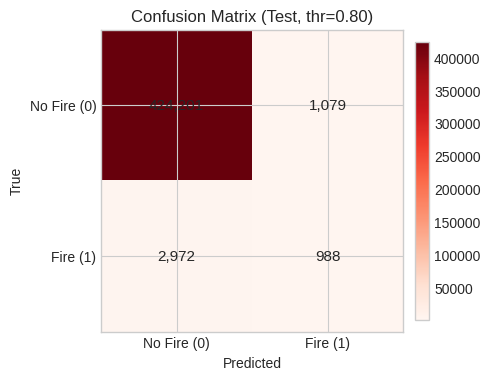

In [18]:
# -------------------------
# Confusion matrix only (TEST @ best threshold)
# -------------------------
import numpy as np
import matplotlib.pyplot as plt

cm = np.array([
    [test_best["tn"], test_best["fp"]],
    [test_best["fn"], test_best["tp"]],
], dtype=np.int64)

fig, ax = plt.subplots(figsize=(4.8, 4.4), constrained_layout=True)
im = ax.imshow(cm, cmap="Reds")

ax.set_title(f"Confusion Matrix (Test, thr={best_thr:.2f})")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_xticks([0, 1]); ax.set_xticklabels(["No Fire (0)", "Fire (1)"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["No Fire (0)", "Fire (1)"])

for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=11)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

## Date-Level Visualizations

Render a chosen date from the loader to compare the ground-truth fire map and the model prediction on the same spatial grid.


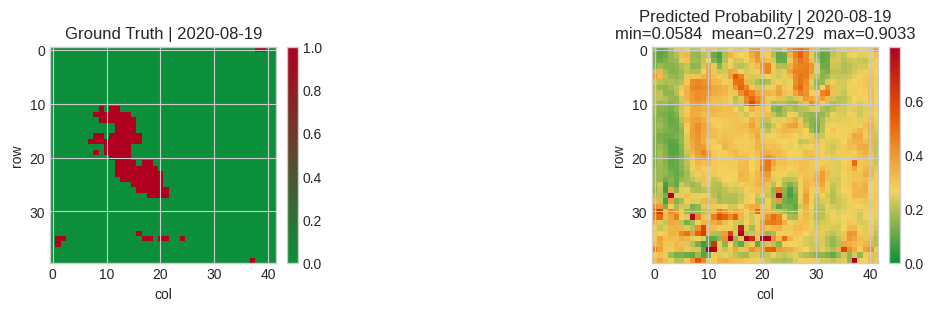

In [24]:
# -------------------------
# Visualize predictions by specific dates
# (Green → Red fire scale)
# -------------------------
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# -------------------------
# Custom colormaps
# -------------------------
fire_cmap = LinearSegmentedColormap.from_list(
    "green_to_fire",
    ["#0B8F3A", "#F4D35E", "#E85D04", "#B00020"]  # green → yellow → orange → red
)

gt_cmap = LinearSegmentedColormap.from_list(
    "gt_green_red",
    ["#0B8F3A", "#B00020"]  # no fire → fire
)

# -------------------------
# choose loader + dates you want
# -------------------------
LOADER = train_loader
TARGET_DATES = [
    "2020-08-19"
]

def day_ts(x):
    """Normalize different date formats to UTC day-start epoch seconds (int)."""
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu().item()
    elif isinstance(x, np.ndarray):
        x = x.item()
    if isinstance(x, (int, np.integer, float, np.floating)):
        return int(x)
    return int(pd.to_datetime(x, utc=True).floor("D").value // 1_000_000_000)

# -------------------------
# requested timestamps in order
# -------------------------
target_ts_order = [
    int(pd.to_datetime(d, utc=True).floor("D").value // 1_000_000_000)
    for d in TARGET_DATES
]
target_ts_set = set(target_ts_order)

# -------------------------
# collect matching samples by date
# -------------------------
found = {}  # ts -> (x1, y1, ts)
for batch in LOADER:
    x_b = batch["x"]   # [B,T,C,H,W]
    y_b = batch["y"]   # [B,H,W]
    d_b = batch["date"]

    B = x_b.shape[0]
    for i in range(B):
        ts = day_ts(d_b[i])
        if ts in target_ts_set and ts not in found:
            found[ts] = (x_b[i:i+1], y_b[i].cpu().numpy(), ts)

    if len(found) == len(target_ts_set):
        break

missing = [d for d, ts in zip(TARGET_DATES, target_ts_order) if ts not in found]
if missing:
    print("Missing dates in selected loader:", missing)

targets = [found[ts] for ts in target_ts_order if ts in found]
if len(targets) == 0:
    raise ValueError("No requested dates found in this loader.")

# -------------------------
# run model
# -------------------------
preds = []
model.eval()

for x1, _, _ in targets:
    with torch.no_grad():
        p1 = torch.sigmoid(model(x1.to(device))).cpu().numpy()[0]  # [H,W]
    preds.append(p1)

# -------------------------
# shared color scale (robust)
# -------------------------
all_probs = np.concatenate([p.ravel() for p in preds])
vmax = float(np.quantile(all_probs, 0.995))
vmax = max(vmax, 1e-4)

# -------------------------
# plot
# -------------------------
n = len(targets)
fig, axes = plt.subplots(n, 2, figsize=(12, 3 * n), constrained_layout=True)

if n == 1:
    axes = np.array([axes])

for r, ((_, y1, ts), p1) in enumerate(zip(targets, preds)):
    d_txt = pd.to_datetime(ts, unit="s", utc=True).date().isoformat()

    # Ground truth (green/red)
    im0 = axes[r, 0].imshow(y1, cmap=gt_cmap, vmin=0, vmax=1)
    axes[r, 0].set_title(f"Ground Truth | {d_txt}")

    # Prediction (green → red heat)
    im1 = axes[r, 1].imshow(p1, cmap=fire_cmap, vmin=0.0, vmax=vmax)
    axes[r, 1].set_title(
        f"Predicted Probability | {d_txt}\n"
        f"min={p1.min():.4f}  mean={p1.mean():.4f}  max={p1.max():.4f}"
    )

    for c in range(2):
        axes[r, c].set_xlabel("col")
        axes[r, c].set_ylabel("row")

    plt.colorbar(im0, ax=axes[r, 0], fraction=0.045, pad=0.02)
    plt.colorbar(im1, ax=axes[r, 1], fraction=0.045, pad=0.02)

plt.show()

## Sample Gallery

Show a small gallery of test samples to inspect prediction quality across multiple examples rather than a single date.


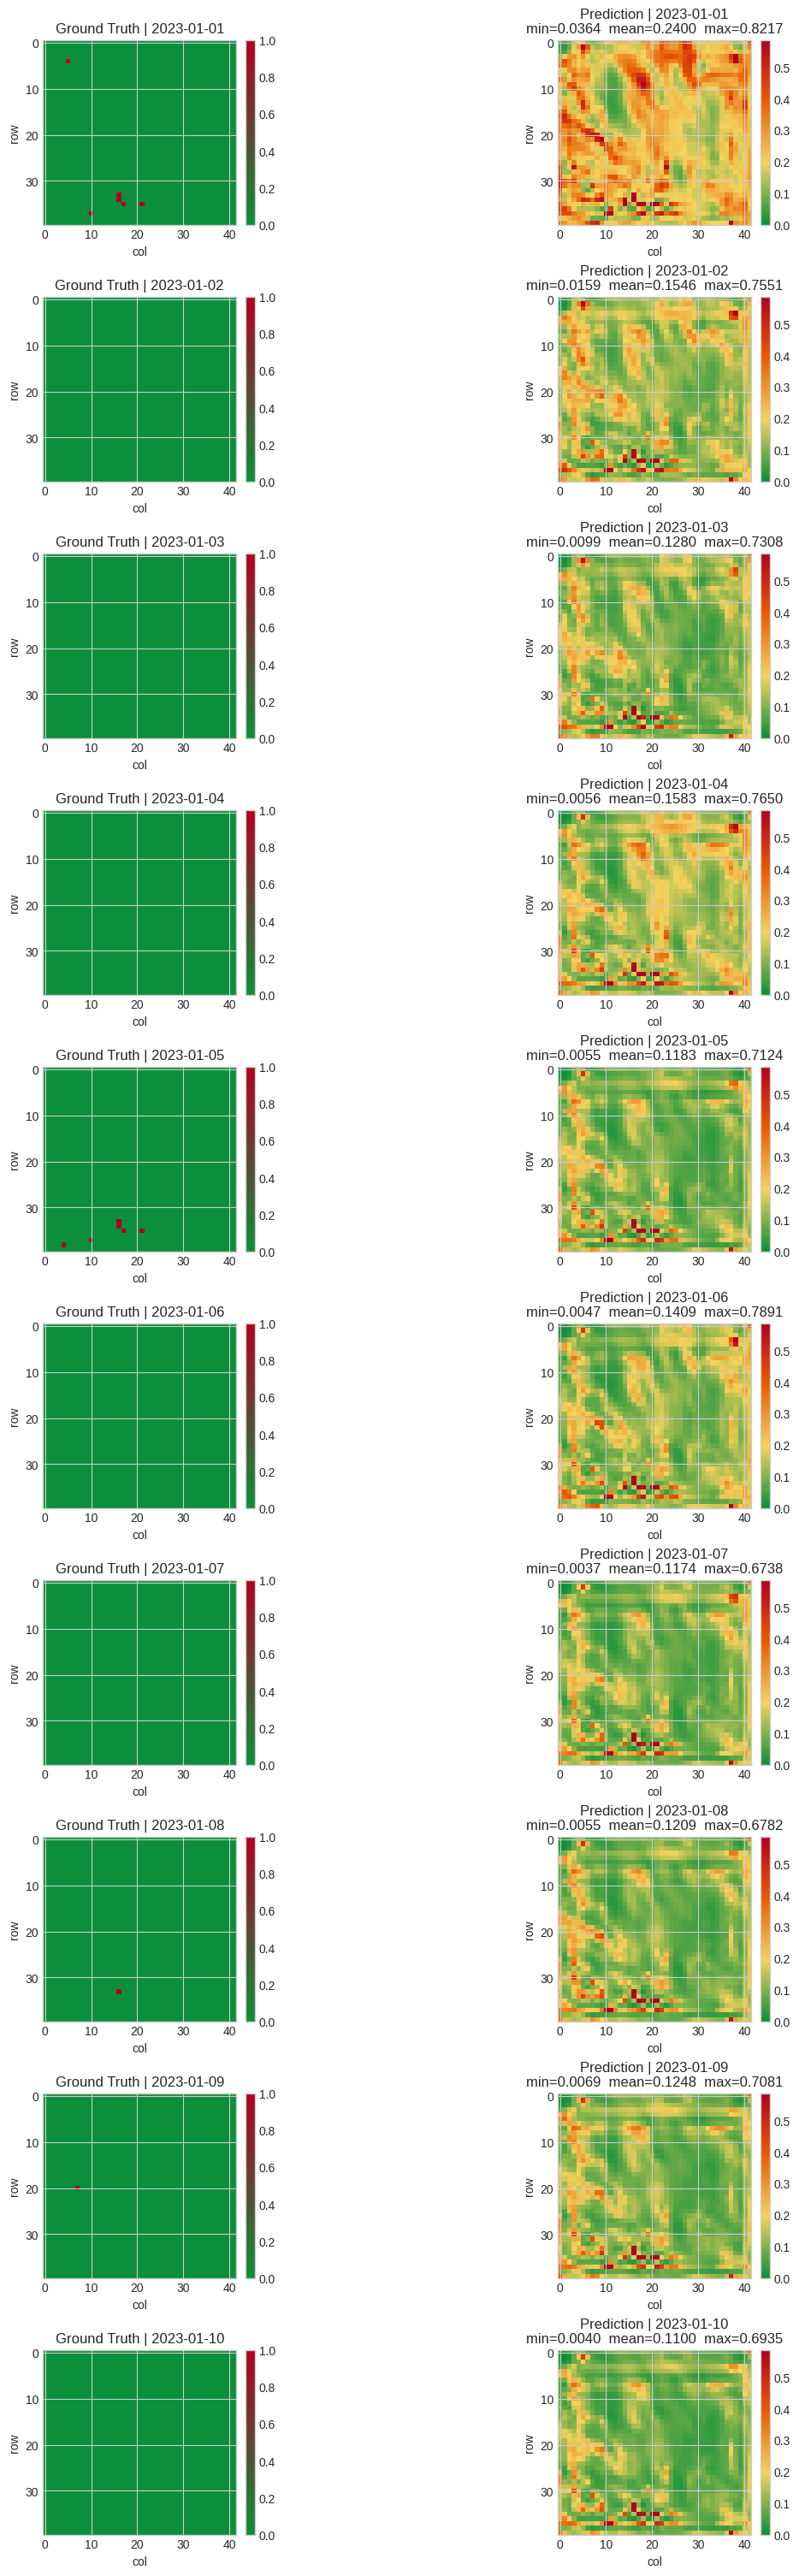

In [20]:
# -------------------------
# Visualize predictions (Green → Red fire scale)
# -------------------------
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# -------------------------
# Custom colormaps
# -------------------------
fire_cmap = LinearSegmentedColormap.from_list(
    "green_to_fire",
    ["#0B8F3A", "#F4D35E", "#E85D04", "#B00020"]  # green → yellow → orange → red
)

gt_cmap = LinearSegmentedColormap.from_list(
    "gt_green_red",
    ["#0B8F3A", "#B00020"]  # no fire → fire
)

# -------------------------
# Select samples (from test_loader)
# -------------------------
targets = []
for batch in test_loader:
    x_b = batch["x"]            # [B,T,C,H,W]
    y_b = batch["y"]            # [B,H,W]
    d_b = batch["date"]

    for i in range(x_b.shape[0]):
        targets.append((x_b[i:i+1], y_b[i].cpu().numpy(), d_b[i]))
        if len(targets) == 10:
            break
    if len(targets) == 10:
        break

if len(targets) == 0:
    raise ValueError("No samples found in loader.")

# -------------------------
# Model inference
# -------------------------
preds = []
model.eval()

for x1, _, _ in targets:
    with torch.no_grad():
        p1 = torch.sigmoid(model(x1.to(device))).cpu().numpy()[0]
    preds.append(p1)

# -------------------------
# Shared scaling (robust)
# -------------------------
all_probs = np.concatenate([p.ravel() for p in preds])
vmax = float(np.quantile(all_probs, 0.995))
vmax = max(vmax, 1e-4)

# -------------------------
# Plot
# -------------------------
n = len(targets)
fig, axes = plt.subplots(n, 2, figsize=(12, 3*n), constrained_layout=True)

if n == 1:
    axes = np.array([axes])

for r, ((_, y1, d1), p1) in enumerate(zip(targets, preds)):

    # date formatting
    if isinstance(d1, (int, np.integer)):
        d_txt = pd.to_datetime(int(d1), unit="s", utc=True).date().isoformat()
    else:
        d_txt = str(d1)

    # Ground truth (green/red)
    im0 = axes[r, 0].imshow(y1, cmap=gt_cmap, vmin=0, vmax=1)
    axes[r, 0].set_title(f"Ground Truth | {d_txt}")

    # Prediction (green → red heat)
    im1 = axes[r, 1].imshow(p1, cmap=fire_cmap, vmin=0.0, vmax=vmax)
    axes[r, 1].set_title(
        f"Prediction | {d_txt}\n"
        f"min={p1.min():.4f}  mean={p1.mean():.4f}  max={p1.max():.4f}"
    )

    for c in range(2):
        axes[r, c].set_xlabel("col")
        axes[r, c].set_ylabel("row")

    plt.colorbar(im0, ax=axes[r, 0], fraction=0.045, pad=0.02)
    plt.colorbar(im1, ax=axes[r, 1], fraction=0.045, pad=0.02)

plt.show()

## Export Pixel Predictions

Write pixel-level predictions to a parquet file so the results can be analyzed outside the notebook or uploaded as an artifact.


In [21]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch

def save_pixel_predictions(model, loader, device, out_path):
    rows = []
    model.eval()
    with torch.no_grad():
        for batch in loader:
            x = batch["x"].to(device, non_blocking=True)          # [B,T,C,H,W]
            y = batch["y"].cpu().numpy().astype(np.uint8)         # [B,H,W]
            p = torch.sigmoid(model(x)).cpu().numpy().astype(np.float32)  # [B,H,W]
            d = batch["date"]

            B, H, W = y.shape
            rr, cc = np.indices((H, W))

            for i in range(B):
                ts = d[i]
                if isinstance(ts, torch.Tensor):
                    ts = int(ts.item())
                elif isinstance(ts, np.ndarray):
                    ts = int(ts.item())
                else:
                    ts = int(ts)

                df_i = pd.DataFrame({
                    "timestamp": np.full(H * W, ts, dtype=np.int64),
                    "row": rr.ravel().astype(np.int16),
                    "col": cc.ravel().astype(np.int16),
                    "y_true": y[i].ravel().astype(np.uint8),
                    "prob": p[i].ravel().astype(np.float32),
                })
                rows.append(df_i)

    out_df = pd.concat(rows, ignore_index=True)
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    out_df.to_parquet(out_path, index=False)
    print("Saved:", out_path, "rows:", len(out_df))

# Example usage:
save_pixel_predictions(model, test_loader, device, "results/no_quantitative_features_preds.parquet")


Saved: results/no_quantitative_features_preds.parquet rows: 613200


## SHAP Explainability

Compute approximate channel-level SHAP scores to identify which feature channels contribute most to the model's output.


In [22]:
# -------------------------
# Shapley feature importance (approximate, channel-level)
# -------------------------
import time

SHAP_NUM_SAMPLES = 10          # number of test windows to explain
SHAP_NUM_PERMUTATIONS = 6      # permutations per sample
SHAP_BASELINE_BATCHES = 20     # batches from train loader to estimate baseline channel values
SHAP_PREFER_FIRE_DAYS = True   # prefer samples with fire pixels
SHAP_MAX_CHANNELS = None       # set e.g. 32 to reduce runtime if C is large
SHAP_SEED = 42
SHAP_TOPK_PLOT = 20
SHAP_SAVE_PATH = WORKDIR / 'shap_channel_importance.csv'


def _to_int_date(v):
    if isinstance(v, torch.Tensor):
        return int(v.detach().cpu().item())
    if isinstance(v, np.ndarray):
        return int(v.item())
    return int(v)


@torch.no_grad()
def estimate_channel_baseline(loader, max_batches=20):
    acc = None
    n = 0
    for bi, batch in enumerate(loader):
        x = batch['x'].to(torch.float32)  # [B,T,C,H,W]
        mu = x.mean(dim=(0, 1, 3, 4))     # [C]
        acc = mu if acc is None else (acc + mu)
        n += 1
        if n >= max_batches:
            break
    if n == 0:
        raise ValueError('No batches available to estimate SHAP baseline.')
    return (acc / n).to(device)


def collect_shap_samples(loader, max_samples=10, prefer_fire=True):
    samples = []
    for batch in loader:
        B = batch['x'].shape[0]
        for i in range(B):
            x = batch['x'][i:i+1].to(device)  # [1,T,C,H,W]
            y = batch['y'][i].to(device)       # [H,W]

            m = batch.get('mask')
            if m is None:
                m_bool = torch.ones_like(y, dtype=torch.bool, device=device)
            else:
                mi = m[i].to(device)
                m_bool = mi if mi.dtype == torch.bool else (mi > 0.5)

            fire_count = int(((y > 0.5) & m_bool).sum().item())
            if prefer_fire and fire_count == 0:
                continue

            ts = _to_int_date(batch['date'][i])
            samples.append((x, y, m_bool, ts))
            if len(samples) >= max_samples:
                return samples
    return samples


@torch.no_grad()
def shap_utility(model, x, y, m_bool):
    """Utility for Shapley: average predicted fire probability on valid pixels,
    preferring true-fire pixels when available."""
    pred = torch.sigmoid(model(x))[0]  # [H,W]
    valid = m_bool.bool()
    fire = (y > 0.5) & valid
    if torch.any(fire):
        return float(pred[fire].mean().item())
    return float(pred[valid].mean().item())


@torch.no_grad()
def estimate_channel_variance(loader, max_batches=8):
    acc1 = None
    acc2 = None
    n = 0
    for bi, batch in enumerate(loader):
        x = batch['x'].to(torch.float32)      # [B,T,C,H,W]
        flat = x.permute(2, 0, 1, 3, 4).reshape(x.shape[2], -1)  # [C, Npix]
        s1 = flat.mean(dim=1)
        s2 = (flat * flat).mean(dim=1)
        acc1 = s1 if acc1 is None else (acc1 + s1)
        acc2 = s2 if acc2 is None else (acc2 + s2)
        n += 1
        if n >= max_batches:
            break
    if n == 0:
        raise ValueError('No data to estimate channel variance.')
    mean = acc1 / n
    mean2 = acc2 / n
    var = torch.clamp(mean2 - mean * mean, min=0.0)
    return var


@torch.no_grad()
def shapley_channel_importance(model, samples, baseline_ch, num_permutations=6, seed=42, channel_subset=None):
    rng = np.random.default_rng(seed)

    C = int(baseline_ch.shape[0])
    if channel_subset is None:
        channels = np.arange(C, dtype=np.int64)
    else:
        channels = np.array(sorted(set(int(c) for c in channel_subset)), dtype=np.int64)

    shap_sum = np.zeros(C, dtype=np.float64)
    counts = np.zeros(C, dtype=np.int64)

    base = baseline_ch.view(1, 1, C, 1, 1)
    model.eval()

    for si, (x, y, m_bool, ts) in enumerate(samples):
        for _ in range(num_permutations):
            perm = rng.permutation(channels)

            # Start from baseline-only input
            x_cur = base.expand_as(x).clone()
            v_prev = shap_utility(model, x_cur, y, m_bool)

            # Add channels one by one
            for ch in perm:
                x_cur[:, :, ch, :, :] = x[:, :, ch, :, :]
                v_new = shap_utility(model, x_cur, y, m_bool)
                shap_sum[ch] += (v_new - v_prev)
                counts[ch] += 1
                v_prev = v_new

        if (si + 1) % 2 == 0:
            print(f'SHAP progress: {si + 1}/{len(samples)} samples')

    shap_vals = np.divide(shap_sum, np.maximum(counts, 1))
    return shap_vals, counts


# 1) Baseline + sample collection
t0 = time.time()
baseline_ch = estimate_channel_baseline(train_loader, max_batches=SHAP_BASELINE_BATCHES)
samples = collect_shap_samples(test_loader, max_samples=SHAP_NUM_SAMPLES, prefer_fire=SHAP_PREFER_FIRE_DAYS)

if len(samples) == 0:
    raise ValueError('No SHAP samples found. Try SHAP_PREFER_FIRE_DAYS=False or increase SHAP_NUM_SAMPLES.')

C_total = int(samples[0][0].shape[2])

# Optional channel subset for speed (top-variance channels)
channel_subset = None
if SHAP_MAX_CHANNELS is not None and C_total > SHAP_MAX_CHANNELS:
    var = estimate_channel_variance(train_loader, max_batches=8).detach().cpu().numpy()
    top_idx = np.argsort(-var)[:int(SHAP_MAX_CHANNELS)]
    channel_subset = sorted(int(i) for i in top_idx)
    print(f'Using top-{len(channel_subset)} variance channels for SHAP approximation.')

# 2) Compute approximate Shapley values
shap_vals, counts = shapley_channel_importance(
    model=model,
    samples=samples,
    baseline_ch=baseline_ch,
    num_permutations=SHAP_NUM_PERMUTATIONS,
    seed=SHAP_SEED,
    channel_subset=channel_subset,
)

# 3) Assemble report
if 'feature_names' in globals() and isinstance(feature_names, list) and len(feature_names) == C_total:
    fnames = feature_names
else:
    fnames = [f'ch_{i}' for i in range(C_total)]

shap_df = pd.DataFrame({
    'channel_index': np.arange(C_total, dtype=int),
    'feature_name': fnames,
    'shap_value': shap_vals.astype(np.float64),
    'abs_shap_value': np.abs(shap_vals.astype(np.float64)),
    'num_marginals': counts.astype(np.int64),
}).sort_values('abs_shap_value', ascending=False).reset_index(drop=True)

shap_df.to_csv(SHAP_SAVE_PATH, index=False)

print('SHAP completed in %.1fs' % (time.time() - t0))
print('Samples used:', len(samples), '| permutations per sample:', SHAP_NUM_PERMUTATIONS)
print('Saved:', SHAP_SAVE_PATH)

display(shap_df.head(30))



SHAP progress: 2/10 samples
SHAP progress: 4/10 samples
SHAP progress: 6/10 samples
SHAP progress: 8/10 samples
SHAP progress: 10/10 samples
SHAP completed in 22.5s
Samples used: 10 | permutations per sample: 6
Saved: /kaggle/working/shap_channel_importance.csv


,channel_index,feature_name,shap_value,abs_shap_value,num_marginals
0,11,rh_min,-0.038740,0.038740,60
1,8,ndvi,0.036811,0.036811,60
2,3,erc,-0.031928,0.031928,60
3,12,temp_max,-0.026074,0.026074,60
4,7,isi,-0.021833,0.021833,60
5,9,precip,0.017133,0.017133,60
6,10,rh_max,0.011574,0.011574,60
7,4,evi,-0.010374,0.010374,60
8,13,temp_min,0.010331,0.010331,60
9,2,dmc,-0.008655,0.008655,60
